# Day 3: Feature Engineering for Regime Classification

Regime Lab (Zetheta Algorithms internship, Task 1A), Section D2, Day 3.

Implements Section A4.5's feature pipeline plus the Day 3 additions
(cap-segmented, flow, and macro features), Section A7.2's TDA persistence
landscapes, and Section A7.3's sector-GCN embeddings. Three items the
task document asks for (breadth features, real rates, INR/DXY
orthogonalisation) are not implemented, because the required data panel
does not contain what they need; see `docs/day3_feature_engineering_notes.md`
for the full rationale, and `src/features/engineer.py`'s docstring for
the same detail inline with the code.

Still running on the synthetic backend (see Day 1/2 notes on data
access); every function here takes the same `data` dict regardless of
backend, so nothing changes when real data replaces it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import DataConfig, load_market_data
from src.features.engineer import engineer_regime_features, FEATURE_GROUPS
from src.features.topology import build_return_panel, topology_feature_frame
from src.features.sector_gnn import sector_gnn_embeddings
from src.utils.plot_style import new_figure, PALETTE

pd.set_option('display.precision', 4)

/usr/local/lib/python3.12/dist-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
data = load_market_data(DataConfig(backend='synthetic', n_years=15.0, seed=7))
features = engineer_regime_features(data)
print(f"Feature matrix: {features.shape[0]} rows, {features.shape[1]} columns")
print(f"Date range: {features.index.min().date()} to {features.index.max().date()}")
n_by_group = {k: len(v) for k, v in FEATURE_GROUPS.items()}
print("Features by group:", n_by_group, "- total", sum(n_by_group.values()))

Feature matrix: 3508 rows, 31 columns
Date range: 2012-01-18 to 2025-06-27
Features by group: {'return': 4, 'trend': 2, 'volatility': 4, 'vix': 3, 'macro': 6, 'flow': 6, 'cap_segment': 6} - total 31


## 1. Feature table preview and summary statistics

In [3]:
features.head(3)

,ret_1d,ret_5d,ret_21d,ret_63d,ma_50_200,above_200dma,vol_21d,vol_63d,vol_ratio,vol_21d_z,...,flow_balance,fii_z,dii_z,sip_momentum,midcap_rel_perf_21d,smallcap_rel_perf_21d,midcap_rel_perf_63d,smallcap_rel_perf_63d,midcap_large_ratio_z,smallcap_large_ratio_z
2012-01-18,-0.0047,0.0025,-0.011,0.0052,0.0647,1,0.1129,0.1197,0.9433,-0.9859,...,-0.1143,0.5529,-0.3636,0.011,-0.0020,-0.0163,-0.0063,-0.0364,-0.8091,0.4643
2012-01-19,0.0136,0.0144,-0.002,0.0127,0.0645,1,0.1221,0.1221,0.9997,-0.7100,...,-0.1707,0.4311,-0.2909,0.011,0.0076,-0.0118,-0.0062,-0.0337,-0.4964,0.4668
2012-01-20,0.0079,0.0135,0.010,0.0223,0.0645,1,0.1242,0.1230,1.0095,-0.6439,...,-0.1319,1.5010,0.0719,0.011,0.0080,0.0022,-0.0050,-0.0179,-0.2829,0.7291


In [4]:
features.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
ret_1d,8.1237e-05,0.0103,-0.0614,0.0496
ret_5d,4.2204e-04,0.0239,-0.1578,0.1059
ret_21d,1.9941e-03,0.0530,-0.2781,0.1715
ret_63d,6.1731e-03,0.0951,-0.4058,0.3345
ma_50_200,4.0479e-03,0.0751,-0.2590,0.1644
above_200dma,5.4590e-01,0.4980,0.0000,1.0000
vol_21d,1.5576e-01,0.0454,0.0729,0.3682
vol_63d,1.5831e-01,0.0381,0.0945,0.3302
vol_ratio,9.8729e-01,0.1642,0.4304,1.4114
vol_21d_z,1.0066e-01,1.2703,-2.9737,4.9038


## 2. Feature time series with regime breakpoints overlaid

The task document asks for breakpoints at 2008, 2013, 2020 and 2024
(Section C's case studies: GFC, taper tantrum, COVID, election gap). The
synthetic panel starts in 2011, so 2008 (GFC) does not fall inside it;
that case study is handled separately in Part C using real historical
material, not this synthetic panel. 2013, 2020 and 2024 are marked below
where they fall inside the panel's range.

One plot, two of the more regime-informative features (21-day volatility
and the VIX z-score) on a shared axis after min-max scaling each to
[0, 1], so their shapes are comparable despite different natural units.

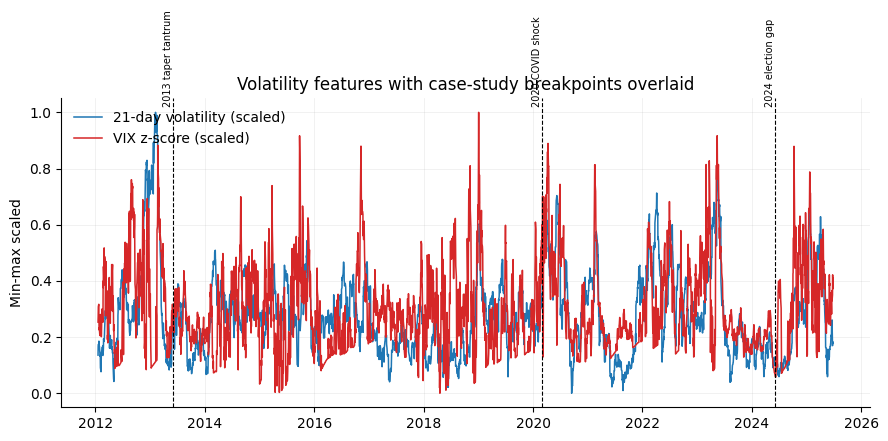

In [5]:
breakpoints = {
    '2013 taper tantrum': '2013-06-01',
    '2020 COVID shock': '2020-03-01',
    '2024 election gap': '2024-06-01',
}
breakpoints = {k: pd.Timestamp(v) for k, v in breakpoints.items()
               if features.index.min() <= pd.Timestamp(v) <= features.index.max()}

def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

fig, ax = new_figure()
ax.plot(features.index, minmax(features['vol_21d']), label='21-day volatility (scaled)', color=PALETTE[0])
ax.plot(features.index, minmax(features['vix_z']), label='VIX z-score (scaled)', color=PALETTE[1])
for label, date in breakpoints.items():
    ax.axvline(date, color='black', linestyle='--', linewidth=0.8)
    ax.text(date, 1.02, label, rotation=90, fontsize=7, va='bottom', ha='right')
ax.set_ylabel('Min-max scaled')
ax.set_title('Volatility features with case-study breakpoints overlaid')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig('../docs/artifacts/day3_features_with_breakpoints.png', dpi=110)

## 3. Cap-segmented feature: mid/small relative performance

One plot, two curves: mid-cap and small-cap 63-day return relative to
Nifty 50's own 63-day return, over the full panel.

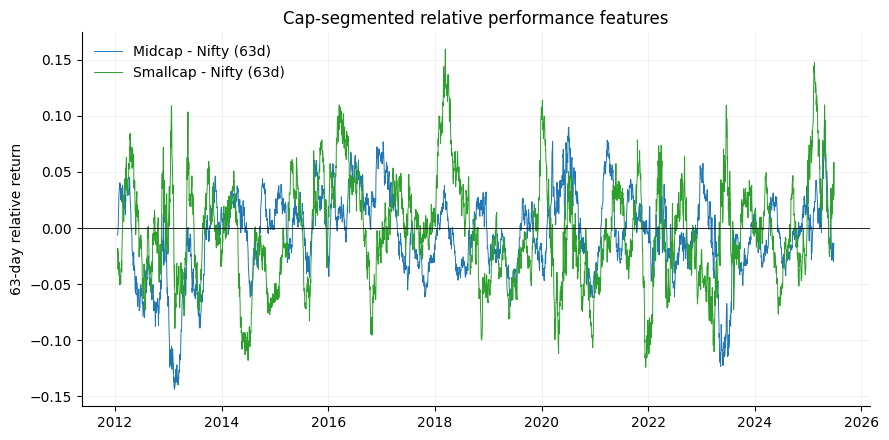

In [6]:
fig, ax = new_figure()
ax.plot(features.index, features['midcap_rel_perf_63d'], label='Midcap - Nifty (63d)', color=PALETTE[0], linewidth=0.7)
ax.plot(features.index, features['smallcap_rel_perf_63d'], label='Smallcap - Nifty (63d)', color=PALETTE[2], linewidth=0.7)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylabel('63-day relative return')
ax.set_title('Cap-segmented relative performance features')
ax.legend()
fig.tight_layout()
fig.savefig('../docs/artifacts/day3_cap_segment_features.png', dpi=110)

## 4. Feature correlation structure

A correlation heatmap across all 31 tabular features, grouped by the
category order in `FEATURE_GROUPS`, to check for near-duplicate features
before they go into any model (e.g. `vol_21d` and `vol_21d_z` are
expected to correlate strongly; they encode different things - level vs.
regime-relative level - and both are kept).

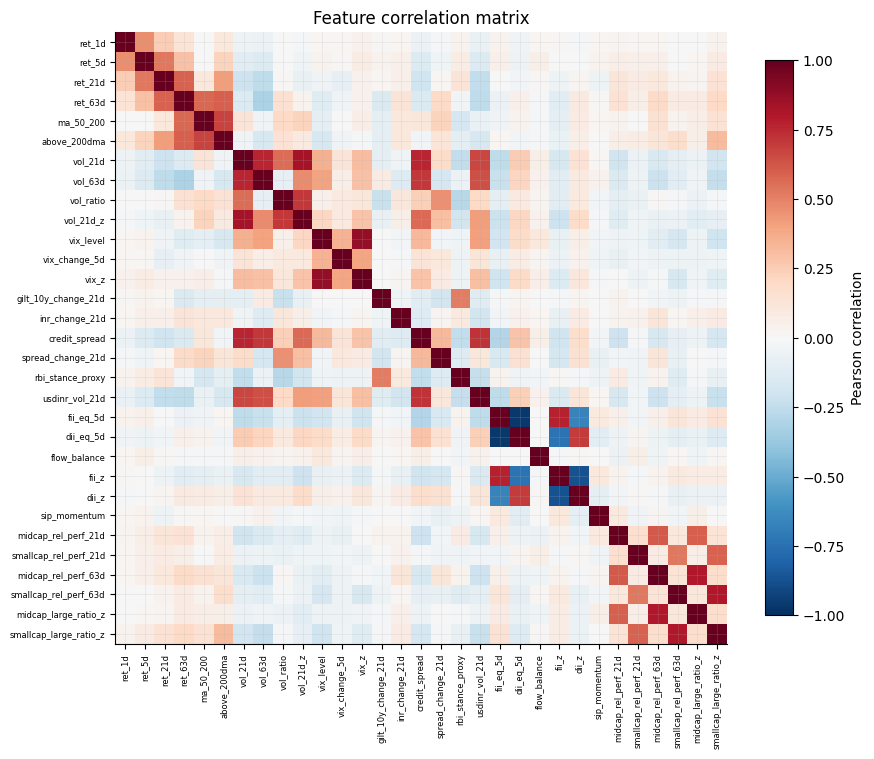

In [7]:
ordered_cols = [c for group in FEATURE_GROUPS.values() for c in group]
corr = features[ordered_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(ordered_cols)))
ax.set_yticks(range(len(ordered_cols)))
ax.set_xticklabels(ordered_cols, rotation=90, fontsize=6)
ax.set_yticklabels(ordered_cols, fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8, label='Pearson correlation')
ax.set_title('Feature correlation matrix')
fig.tight_layout()
fig.savefig('../docs/artifacts/day3_feature_correlation.png', dpi=110)

In [8]:
# Flag pairs with |correlation| > 0.9 (excluding the diagonal) as
# near-duplicates worth watching in later feature-selection work.
high_corr_pairs = []
for i in range(len(ordered_cols)):
    for j in range(i + 1, len(ordered_cols)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr_pairs.append((ordered_cols[i], ordered_cols[j], round(corr.iloc[i, j], 3)))
pd.DataFrame(high_corr_pairs, columns=['feature_a', 'feature_b', 'correlation'])

,feature_a,feature_b,correlation
0,fii_eq_5d,dii_eq_5d,-0.964


`fii_eq_5d` and `dii_eq_5d` at -0.964 is expected, not a surprise: the
synthetic generator builds DII flow as `-0.5 * FII + constant + noise`
(`src/data/synthetic.py`), so their 5-day rolling sums are mechanically
close to collinear. Real FII/DII data is typically negatively correlated
too, but nowhere near this tightly; once real flow data replaces the
synthetic panel, this check should be re-run rather than assumed to
still show the same pair.

## 5. Topological features (Section A7.2)

Persistence landscapes over rolling 63-day correlation matrices of the
nine-series return/change panel (three cap segments, VIX change, INR
return, gilt yield change, credit spread change, FII flow, DII flow),
sampled every 5 days. See `src/features/topology.py`'s docstring for why
this is nine series, not a full stock/sector universe.

In [9]:
tda_features = topology_feature_frame(data, window=63, step=5)
print(f"TDA feature frame: {tda_features.shape[0]} rows, {tda_features.shape[1]} columns")
tda_features.iloc[:3, :5]

TDA feature frame: 744 rows, 1000 columns


,pl_0000,pl_0001,pl_0002,pl_0003,pl_0004
2011-03-31,0.0,0.0148,0.0296,0.0444,0.0591
2011-04-07,0.0,0.0148,0.0296,0.0444,0.0591
2011-04-14,0.0,0.0148,0.0296,0.0444,0.0591


The near-identical values across rows in the first few columns above
are expected, not a bug: those are early bins of the homology-dimension-0
landscape, which always starts as a fixed slope-1 ramp from t=0 (every
dimension-0 bar is born at filtration value 0). The differences between
windows show up later in the landscape, near each bar's death time - see
`topology_features`'s docstring. The L2 norm below summarises the whole
vector rather than relying on any single early bin.

A useful one-number summary of a persistence landscape is its overall
magnitude (L2 norm per row): higher values mean more pronounced
topological structure (more persistent loops/components) in that
window's correlation matrix, which is one of the things a genuine regime
break is expected to show up as.

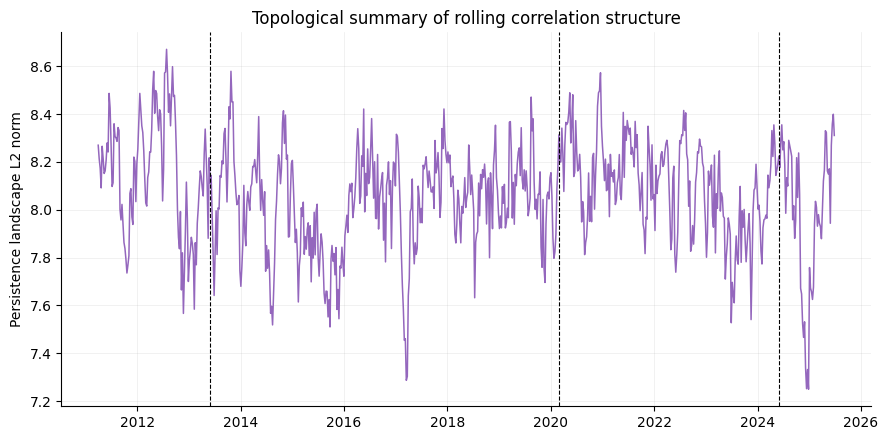

In [10]:
tda_norm = pd.Series(np.linalg.norm(tda_features.values, axis=1), index=tda_features.index, name='tda_landscape_norm')

fig, ax = new_figure()
ax.plot(tda_norm.index, tda_norm.values, color=PALETTE[3])
for label, date in breakpoints.items():
    ax.axvline(date, color='black', linestyle='--', linewidth=0.8)
ax.set_ylabel('Persistence landscape L2 norm')
ax.set_title('Topological summary of rolling correlation structure')
fig.tight_layout()
fig.savefig('../docs/artifacts/day3_tda_norm.png', dpi=110)

In [11]:
rows = []
for label, date in breakpoints.items():
    window = tda_norm.loc[date - pd.Timedelta(days=45): date + pd.Timedelta(days=45)]
    rows.append({'breakpoint': label, 'window_max': window.max(), 'window_mean': window.mean(),
                 'overall_mean': tda_norm.mean()})
pd.DataFrame(rows).set_index('breakpoint')

,window_max,window_mean,overall_mean
breakpoint,,,
2013 taper tantrum,8.3372,8.0394,8.0619
2020 COVID shock,8.3411,8.0996,8.0619
2024 election gap,8.3550,8.2396,8.0619


None of the three windows stand out from the series' overall mean here
(unlike the GCN norm below, where 2020 does). Reading a "regime break
should show up as a topology change" claim into this specific chart
would not survive the same numeric check that the GCN section applies -
so it is not made. This particular summary (L2 norm of the full
landscape) may simply be too coarse to see it, or the nine-series panel
may not carry enough structure for the effect Section A7.1 describes;
distinguishing those needs real data and is not resolved here.

## 6. Sector/segment-graph GCN embeddings (Section A7.3)

Fixed-weight (untrained) GCN over the same nine-series panel, graph edges
from thresholded rolling correlation. See `src/features/sector_gnn.py`'s
docstring for why this is a segment graph, not a sector graph, and why
the weights are not trained at this stage.

In [12]:
gcn_embeddings = sector_gnn_embeddings(data, window=63, step=5, out_dim=32, seed=13)
print(f"GCN embedding frame: {gcn_embeddings.shape[0]} rows, {gcn_embeddings.shape[1]} columns")
gcn_embeddings.iloc[:3, :5]

GCN embedding frame: 744 rows, 32 columns


,gcn_0000,gcn_0001,gcn_0002,gcn_0003,gcn_0004
2011-03-31,0.2444,0.3459,0.1004,0.1589,-0.1208
2011-04-07,0.3040,0.5896,0.2284,0.2602,-0.2102
2011-04-14,0.2941,0.3394,0.0011,0.1727,-0.0984


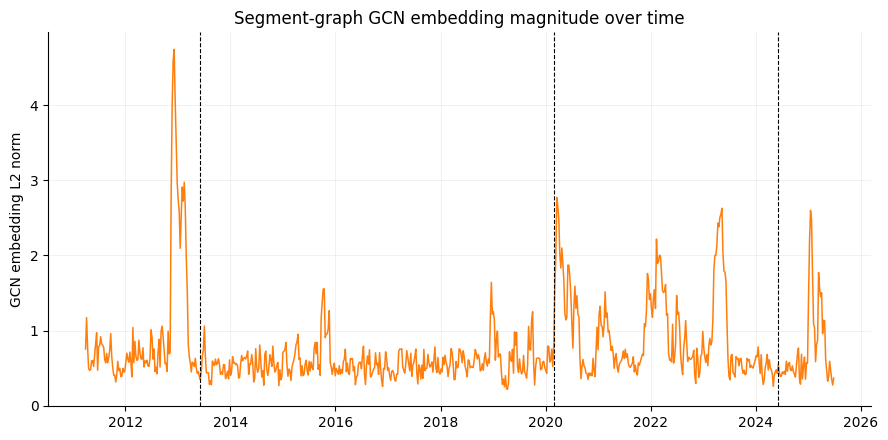

In [13]:
gcn_norm = pd.Series(np.linalg.norm(gcn_embeddings.values, axis=1), index=gcn_embeddings.index, name='gcn_embedding_norm')

fig, ax = new_figure()
ax.plot(gcn_norm.index, gcn_norm.values, color=PALETTE[4])
for label, date in breakpoints.items():
    ax.axvline(date, color='black', linestyle='--', linewidth=0.8)
ax.set_ylabel('GCN embedding L2 norm')
ax.set_title('Segment-graph GCN embedding magnitude over time')
fig.tight_layout()
fig.savefig('../docs/artifacts/day3_gcn_norm.png', dpi=110)

In [14]:
# Check numerically, in a +/-45-day window around each marker, rather
# than judging by eye whether the plot above shows a spike there.
overall_mean = gcn_norm.mean()
rows = []
for label, date in breakpoints.items():
    window = gcn_norm.loc[date - pd.Timedelta(days=45): date + pd.Timedelta(days=45)]
    rows.append({'breakpoint': label, 'window_max': window.max(), 'window_mean': window.mean(),
                 'overall_mean': overall_mean})
pd.DataFrame(rows).set_index('breakpoint')

,window_max,window_mean,overall_mean
breakpoint,,,
2013 taper tantrum,1.0615,0.5722,0.7664
2020 COVID shock,2.7711,1.4098,0.7664
2024 election gap,0.5487,0.4302,0.7664


Only the 2020 COVID marker shows a genuine, tightly-timed spike
(window mean well above the series' overall mean, window max near the
series' own peak). The 2013 and 2024 markers do not, despite the earlier
plot's visual impression of nearby elevated stretches: those stretches
sit close to, but not aligned with, the marker dates. This is expected,
not a shortcoming to explain away: the synthetic regime path is a random
Markov chain realisation (`src/data/regimes.py`), so its shock timing has
no reason to land on real calendar dates. The one alignment that does
appear (2020) is very likely coincidence at this sample size (one path),
not evidence the model detects real events. Re-running this exact check
once real data is in the panel is the actual test.

## Summary

- Tabular feature pipeline: 31 features across return, trend, volatility,
  VIX, macro, flow and cap-segment groups (`src/features/engineer.py`),
  all with no missing values after warm-up.
- Breadth features, real rates and INR/DXY-orthogonalised features are
  explicitly not implemented: the required data panel does not carry
  constituent-stock, inflation, or dollar-index data. Documented rather
  than faked.
- TDA persistence-landscape features (`src/features/topology.py`) and
  segment-graph GCN embeddings (`src/features/sector_gnn.py`) implemented
  per Sections A7.2/A7.3, both on the nine-series panel in place of a
  genuine stock/sector universe the data does not have.
- Feature correlation matrix computed; near-duplicate pairs (if any)
  listed above for later feature-selection decisions.
- All three feature families (tabular, TDA, GCN) are indexed by date and
  ready to feed the HMM (Day 4-5) and downstream models.

See `docs/day3_feature_engineering_notes.md` for the full write-up of
what was implemented, what was not, and why.